# Market Structured Bars

## Overview

This notebook demonstrates the public functions in `market_structured_bars`.
- Problem: fixed time intervals can mix periods with materially different market activity.
- Approach: construct standard, imbalance, and run bars from observed data.

## Observed Data

This cell loads the selected market data used by every example below.
- `data_path` identifies `../../data/research_data/market/data/source_file` as the source file.
- `feature_dir` identifies `../../data/research_data/market/features/` as the output directory.
- `symbol_slug` and `period_slug` preserve the source symbol and requested date range in each output filename.
- `timestamp` identifies the market minute in UTC.
- `symbol` identifies the traded instrument.
- `price` contains the observed close price in dollars.
- `size` contains the total number of shares traded.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

from src.data_preprocessing.market_structured_bars import (
    get_dollar_bars,
    get_dollar_imbalance_bars,
    get_dollar_run_bars,
    get_tick_bars,
    get_tick_imbalance_bars,
    get_tick_run_bars,
    get_volume_bars,
    get_volume_imbalance_bars,
    get_volume_run_bars,
    save_structured_bar_result,
)

data_path = Path("../../data/research_data/market/data/aapl_2025-01-01_2025-12-31.parquet")
feature_dir = data_path.parent.parent / "features"
symbol_slug, period_slug = data_path.stem.split("_", 1)
observations = pd.read_parquet(data_path)
observations.head()

,timestamp,symbol,price,size
0,2025-01-02 13:45:58.902948+00:00,AAPL,250.00,20.0
1,2025-01-02 13:52:44.306521+00:00,AAPL,248.97,20.0
2,2025-01-02 13:52:44.306572+00:00,AAPL,248.98,20.0
3,2025-01-02 13:53:04.071807+00:00,AAPL,248.99,20.0
4,2025-01-02 13:53:04.071848+00:00,AAPL,249.00,20.0


## Standard Bars

This cell computes standard bars with fixed illustrative thresholds.
- `standard_thresholds` contains the observation count, share volume, and dollar value thresholds selected for this example.
- `standard_bar_output_paths` contains the output paths for each bar.
- `end` identifies the UTC timestamp of the final observation in each completed bar.
- `start` identifies the UTC timestamp of the first observation in each completed bar.
- `symbol` identifies the instrument represented by the bar.
- `open` contains the first observed price in dollars.
- `high` contains the highest observed price in dollars.
- `low` contains the lowest observed price in dollars.
- `close` contains the final observed price in dollars.
- `volume` contains the total observed share volume.
- `dollar_value` contains the total derived dollar value.
- `ticks` contains the number of one-minute source observations.
- `buy_volume` contains the share volume assigned a positive minute direction.
- `sell_volume` contains the share volume assigned a negative minute direction.

In [2]:
standard_thresholds = {
    "tick": 20,
    "volume": 2_000.0,
    "dollar": 500_000.0,
}

standard_bar_results = {
    "Tick Bar": get_tick_bars(observations, threshold=standard_thresholds["tick"]),
    "Volume Bar": get_volume_bars(observations, threshold=standard_thresholds["volume"]),
    "Dollar Bar": get_dollar_bars(observations, threshold=standard_thresholds["dollar"]),
}

standard_bar_output_paths = {
    "Tick Bar": save_structured_bar_result(
        standard_bar_results["Tick Bar"],
        feature_dir / f"{symbol_slug}_tick_bar_{period_slug}.parquet",
    ),
    "Volume Bar": save_structured_bar_result(
        standard_bar_results["Volume Bar"],
        feature_dir / f"{symbol_slug}_volume_bar_{period_slug}.parquet",
    ),
    "Dollar Bar": save_structured_bar_result(
        standard_bar_results["Dollar Bar"],
        feature_dir / f"{symbol_slug}_dollar_bar_{period_slug}.parquet",
    ),
}

print("Tick Bar")
display(standard_bar_results["Tick Bar"].ohlcv.head(5))

print("Volume Bar")
display(standard_bar_results["Volume Bar"].ohlcv.head(5))

print("Dollar Bar")
display(standard_bar_results["Dollar Bar"].ohlcv.head(5))

Tick Bar


,start,symbol,open,high,low,close,volume,dollar_value,ticks,buy_volume,sell_volume
end,,,,,,,,,,,
2025-01-02 14:30:00.427502+00:00,2025-01-02 13:45:58.902948+00:00,AAPL,250.000,250.000,248.925,248.930,1434.0,356992.290,20,448.0,986.0
2025-01-02 14:30:01.547491+00:00,2025-01-02 14:30:00.465521+00:00,AAPL,248.930,248.960,248.810,248.820,1360.0,338482.485,20,837.0,523.0
2025-01-02 14:30:01.975434+00:00,2025-01-02 14:30:01.547958+00:00,AAPL,248.785,248.830,248.620,248.620,1152.0,286593.840,20,682.0,470.0
2025-01-02 14:30:02.460014+00:00,2025-01-02 14:30:01.977683+00:00,AAPL,248.665,248.710,248.590,248.685,895.0,222548.105,20,313.0,582.0
2025-01-02 14:30:02.769496+00:00,2025-01-02 14:30:02.469602+00:00,AAPL,248.640,248.715,248.610,248.610,1045.0,259860.460,20,632.0,413.0


Volume Bar


,start,symbol,open,high,low,close,volume,dollar_value,ticks,buy_volume,sell_volume
end,,,,,,,,,,,
2025-01-02 14:30:01.004279+00:00,2025-01-02 13:45:58.902948+00:00,AAPL,250.000,250.000,248.89,248.91,2114.0,526256.99,25,948.0,1166.0
2025-01-02 14:30:02.119118+00:00,2025-01-02 14:30:01.004306+00:00,AAPL,248.910,248.960,248.61,248.65,2059.0,512254.63,40,1226.0,833.0
2025-01-02 14:30:02.891073+00:00,2025-01-02 14:30:02.129080+00:00,AAPL,248.590,248.715,248.59,248.59,2013.0,500551.56,41,838.0,1175.0
2025-01-02 14:30:04.394582+00:00,2025-01-02 14:30:02.929026+00:00,AAPL,248.645,248.710,248.56,248.61,2018.0,501747.93,23,311.0,1707.0
2025-01-02 14:30:05.069868+00:00,2025-01-02 14:30:04.394604+00:00,AAPL,248.610,248.620,248.56,248.56,2005.0,498432.95,16,1702.0,303.0


Dollar Bar


,start,symbol,open,high,low,close,volume,dollar_value,ticks,buy_volume,sell_volume
end,,,,,,,,,,,
2025-01-02 14:30:01.004279+00:00,2025-01-02 13:45:58.902948+00:00,AAPL,250.000,250.000,248.89,248.91,2114.0,526256.99,25,948.0,1166.0
2025-01-02 14:30:02.119118+00:00,2025-01-02 14:30:01.004306+00:00,AAPL,248.910,248.960,248.61,248.65,2059.0,512254.63,40,1226.0,833.0
2025-01-02 14:30:02.891073+00:00,2025-01-02 14:30:02.129080+00:00,AAPL,248.590,248.715,248.59,248.59,2013.0,500551.56,41,838.0,1175.0
2025-01-02 14:30:04.394582+00:00,2025-01-02 14:30:02.929026+00:00,AAPL,248.645,248.710,248.56,248.61,2018.0,501747.93,23,311.0,1707.0
2025-01-02 14:30:05.084156+00:00,2025-01-02 14:30:04.394604+00:00,AAPL,248.610,248.620,248.56,248.58,2012.0,500173.01,23,1709.0,303.0


## Standard Bar Frequencies

This cell visualizes the raw daily standard-bar counts.
- The horizontal axis represents the observed trading day.
- The vertical axis represents the raw number of completed bars per observed trading day.
- Dollar bars exhibit the most robust daily sampling frequency, followed by volume bars and then tick bars.

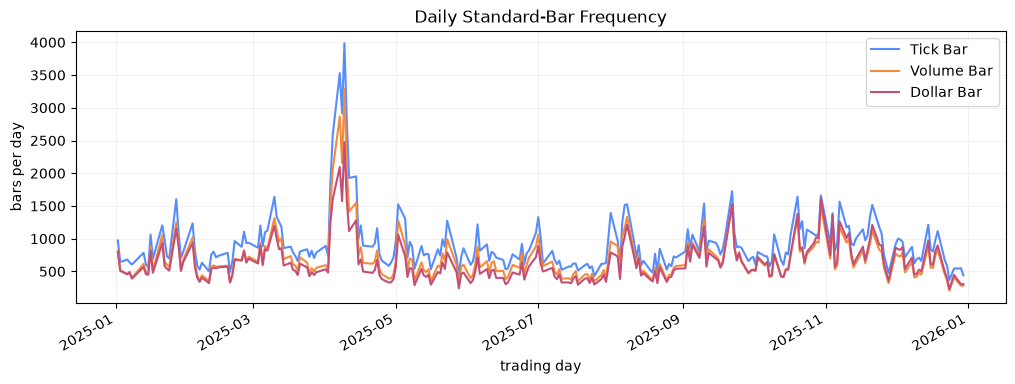

In [3]:
trading_days = pd.DatetimeIndex(
    observations["timestamp"].dt.normalize().drop_duplicates(),
    name="trading_day",
)

standard_daily_bar_counts = pd.DataFrame(
    {
        name: result.ohlcv.groupby(result.ohlcv.index.normalize()).size()
        for name, result in standard_bar_results.items()
    }
).reindex(trading_days).fillna(0).astype(int)
standard_daily_bar_counts.index.name = "trading_day"

ax = standard_daily_bar_counts.plot(figsize=(12, 4), lw=1.5)
ax.set_title("Daily Standard-Bar Frequency")
ax.set_xlabel("trading day")
ax.set_ylabel("bars per day")
ax.grid(alpha=0.25)
plt.show()

## Imbalance Bars

This cell computes adaptive imbalance bars with fixed illustrative parameters.
- `imbalance_bar_parameters` contains the initial expected bar length, recent bar window, and expected imbalance window settings selected for this example.
- `imbalance_bar_output_paths` contains the output paths for each bar.
- `end` identifies the UTC timestamp of the final observation in each completed bar.
- `start` identifies the UTC timestamp of the first observation in each completed bar.
- `symbol` identifies the instrument represented by the bar.
- `open` contains the first observed price in dollars.
- `high` contains the highest observed price in dollars.
- `low` contains the lowest observed price in dollars.
- `close` contains the final observed price in dollars.
- `volume` contains the total observed share volume.
- `dollar_value` contains the total derived dollar value.
- `ticks` contains the number of one-minute source observations.
- `buy_volume` contains the share volume assigned a positive minute direction.
- `sell_volume` contains the share volume assigned a negative minute direction.

In [4]:
imbalance_bar_parameters = {
    "tick": {
        "exp_num_ticks_init": 100,
        "num_prev_bars": 1000,
        "expected_imbalance_window": 1000,
    },
    "volume": {
        "exp_num_ticks_init": 100,
        "num_prev_bars": 1000,
        "expected_imbalance_window": 1000,
    },
    "dollar": {
        "exp_num_ticks_init": 100,
        "num_prev_bars": 1000,
        "expected_imbalance_window": 1000,
    },
}
imbalance_bar_results = {
    "Tick Imbalance Bar": get_tick_imbalance_bars(
        observations,
        **imbalance_bar_parameters["tick"],
    ),
    "Volume Imbalance Bar": get_volume_imbalance_bars(
        observations,
        **imbalance_bar_parameters["volume"],
    ),
    "Dollar Imbalance Bar": get_dollar_imbalance_bars(
        observations,
        **imbalance_bar_parameters["dollar"],
    ),
}

imbalance_bar_output_paths = {
    "Tick Imbalance Bar": save_structured_bar_result(
        imbalance_bar_results["Tick Imbalance Bar"],
        feature_dir / f"{symbol_slug}_tick_imbalance_bar_{period_slug}.parquet",
    ),
    "Volume Imbalance Bar": save_structured_bar_result(
        imbalance_bar_results["Volume Imbalance Bar"],
        feature_dir / f"{symbol_slug}_volume_imbalance_bar_{period_slug}.parquet",
    ),
    "Dollar Imbalance Bar": save_structured_bar_result(
        imbalance_bar_results["Dollar Imbalance Bar"],
        feature_dir / f"{symbol_slug}_dollar_imbalance_bar_{period_slug}.parquet",
    ),
}

print("Tick Imbalance Bar")
display(imbalance_bar_results["Tick Imbalance Bar"].ohlcv.head(5))

print("Volume Imbalance Bar")
display(imbalance_bar_results["Volume Imbalance Bar"].ohlcv.head(5))

print("Dollar Imbalance Bar")
display(imbalance_bar_results["Dollar Imbalance Bar"].ohlcv.head(5))

Tick Imbalance Bar


,start,symbol,open,high,low,close,volume,dollar_value,ticks,buy_volume,sell_volume
end,,,,,,,,,,,
2025-01-02 14:30:02.769496+00:00,2025-01-02 13:45:58.902948+00:00,AAPL,250.00,250.00,248.59,248.61,5886.0,1464477.18,100,2912.0,2974.0
2025-01-02 14:30:02.776636+00:00,2025-01-02 14:30:02.770975+00:00,AAPL,248.61,248.61,248.61,248.61,100.0,24861.00,3,0.0,100.0
2025-01-02 14:30:03.142329+00:00,2025-01-02 14:30:02.782298+00:00,AAPL,248.66,248.69,248.59,248.63,1280.0,318257.30,15,109.0,1171.0
2025-01-02 14:30:05.084156+00:00,2025-01-02 14:30:03.389320+00:00,AAPL,248.71,248.71,248.56,248.58,2950.0,733388.64,34,2011.0,939.0
2025-01-02 14:31:47.114382+00:00,2025-01-02 14:30:05.084183+00:00,AAPL,248.58,249.05,247.59,247.59,28664.0,7124257.01,279,17032.0,11632.0


Volume Imbalance Bar


,start,symbol,open,high,low,close,volume,dollar_value,ticks,buy_volume,sell_volume
end,,,,,,,,,,,
2025-01-02 14:30:02.776375+00:00,2025-01-02 13:45:58.902948+00:00,AAPL,250.000,250.000,248.59,248.610,5964.0,1483868.760,102,2912.0,3052.0
2025-01-02 14:30:02.973128+00:00,2025-01-02 14:30:02.776636+00:00,AAPL,248.610,248.690,248.59,248.670,524.0,130292.580,12,109.0,415.0
2025-01-02 14:30:03.057585+00:00,2025-01-02 14:30:03.002668+00:00,AAPL,248.630,248.630,248.63,248.630,478.0,118845.140,2,0.0,478.0
2025-01-02 14:30:09.673150+00:00,2025-01-02 14:30:03.142296+00:00,AAPL,248.630,248.850,248.53,248.810,7153.0,1778863.060,81,2971.0,4182.0
2025-01-02 14:30:16.080508+00:00,2025-01-02 14:30:10.285033+00:00,AAPL,248.845,248.845,248.41,248.455,4069.0,1011809.305,30,2745.0,1324.0


Dollar Imbalance Bar


,start,symbol,open,high,low,close,volume,dollar_value,ticks,buy_volume,sell_volume
end,,,,,,,,,,,
2025-01-02 14:30:02.776636+00:00,2025-01-02 13:45:58.902948+00:00,AAPL,250.000,250.000,248.59,248.61,5986.0,1489338.180,103,2912.0,3074.0
2025-01-02 14:30:02.973128+00:00,2025-01-02 14:30:02.782298+00:00,AAPL,248.660,248.690,248.59,248.67,502.0,124823.160,11,109.0,393.0
2025-01-02 14:30:03.057585+00:00,2025-01-02 14:30:03.002668+00:00,AAPL,248.630,248.630,248.63,248.63,478.0,118845.140,2,0.0,478.0
2025-01-02 14:30:09.673150+00:00,2025-01-02 14:30:03.142296+00:00,AAPL,248.630,248.850,248.53,248.81,7153.0,1778863.060,81,2971.0,4182.0
2025-01-02 14:30:17.223120+00:00,2025-01-02 14:30:10.285033+00:00,AAPL,248.845,248.845,248.41,248.47,4074.0,1013051.655,31,2750.0,1324.0


## Imbalance Bar Frequencies

This cell visualizes the raw daily imbalance-bar counts.
- The horizontal axis represents the observed trading day.
- The vertical axis represents the raw number of completed bars per observed trading day.
- Dollar imbalance bars exhibit the most robust daily sampling frequency, followed by volume imbalance bars and then tick imbalance bars.

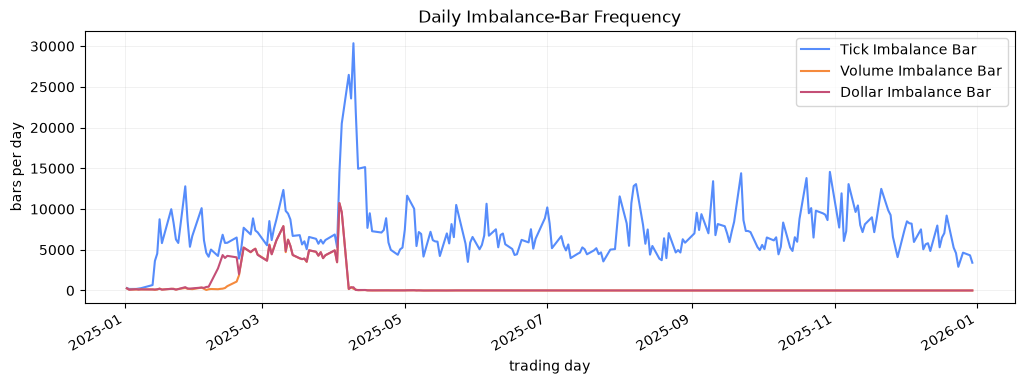

In [5]:
trading_days = pd.DatetimeIndex(
    observations["timestamp"].dt.normalize().drop_duplicates(),
    name="trading_day",
)

imbalance_daily_bar_counts = pd.DataFrame(
    {
        name: result.ohlcv.groupby(result.ohlcv.index.normalize()).size()
        for name, result in imbalance_bar_results.items()
    }
).reindex(trading_days).fillna(0).astype(int)
imbalance_daily_bar_counts.index.name = "trading_day"

ax = imbalance_daily_bar_counts.plot(figsize=(12, 4), lw=1.5)
ax.set_title("Daily Imbalance-Bar Frequency")
ax.set_xlabel("trading day")
ax.set_ylabel("bars per day")
ax.grid(alpha=0.25)
plt.show()

## Run Bars

This cell computes adaptive run bars with fixed illustrative parameters.
- `run_bar_parameters` contains the initial expected bar length, recent bar window, and expected imbalance window settings selected for this example.
- `run_bar_output_paths` contains the output paths for each bar.
- `end` identifies the UTC timestamp of the final observation in each completed bar.
- `start` identifies the UTC timestamp of the first observation in each completed bar.
- `symbol` identifies the instrument represented by the bar.
- `open` contains the first observed price in dollars.
- `high` contains the highest observed price in dollars.
- `low` contains the lowest observed price in dollars.
- `close` contains the final observed price in dollars.
- `volume` contains the total observed share volume.
- `dollar_value` contains the total derived dollar value.
- `ticks` contains the number of one-minute source observations.
- `buy_volume` contains the share volume assigned a positive minute direction.
- `sell_volume` contains the share volume assigned a negative minute direction.

In [6]:
run_bar_parameters = {
    "tick": {
        "exp_num_ticks_init": 100,
        "num_prev_bars": 20,
        "expected_imbalance_window": 1_000,
    },
    "volume": {
        "exp_num_ticks_init": 100,
        "num_prev_bars": 20,
        "expected_imbalance_window": 1_000,
    },
    "dollar": {
        "exp_num_ticks_init": 100,
        "num_prev_bars": 20,
        "expected_imbalance_window": 1_000,
    },
}
run_bar_results = {
    "Tick Run Bar": get_tick_run_bars(
        observations,
        **run_bar_parameters["tick"],
    ),
    "Volume Run Bar": get_volume_run_bars(
        observations,
        **run_bar_parameters["volume"],
    ),
    "Dollar Run Bar": get_dollar_run_bars(
        observations,
        **run_bar_parameters["dollar"],
    ),
}

run_bar_output_paths = {
    "Tick Run Bar": save_structured_bar_result(
        run_bar_results["Tick Run Bar"],
        feature_dir / f"{symbol_slug}_tick_run_bar_{period_slug}.parquet",
    ),
    "Volume Run Bar": save_structured_bar_result(
        run_bar_results["Volume Run Bar"],
        feature_dir / f"{symbol_slug}_volume_run_bar_{period_slug}.parquet",
    ),
    "Dollar Run Bar": save_structured_bar_result(
        run_bar_results["Dollar Run Bar"],
        feature_dir / f"{symbol_slug}_dollar_run_bar_{period_slug}.parquet",
    ),
}

print("Tick Run Bar")
display(run_bar_results["Tick Run Bar"].ohlcv.head(5))

print("Volume Run Bar")
display(run_bar_results["Volume Run Bar"].ohlcv.head(5))

print("Dollar Run Bar")
display(run_bar_results["Dollar Run Bar"].ohlcv.head(5))

Tick Run Bar


,start,symbol,open,high,low,close,volume,dollar_value,ticks,buy_volume,sell_volume
end,,,,,,,,,,,
2025-01-02 14:30:02.770975+00:00,2025-01-02 13:45:58.902948+00:00,AAPL,250.00,250.00,248.59,248.610,5889.0,1465223.010,101,2912.0,2977.0
2025-01-02 14:30:11.700045+00:00,2025-01-02 14:30:02.776375+00:00,AAPL,248.61,248.85,248.53,248.645,10269.0,2553862.270,106,4206.0,6063.0
2025-01-02 14:31:05.315732+00:00,2025-01-02 14:30:11.888654+00:00,AAPL,248.60,248.69,248.01,248.570,14298.0,3552979.295,103,11195.0,3103.0
2025-01-02 14:31:42.255190+00:00,2025-01-02 14:31:06.415325+00:00,AAPL,248.66,249.05,248.07,248.070,7254.0,1803199.925,107,3538.0,3716.0
2025-01-02 14:32:50.387498+00:00,2025-01-02 14:31:42.255205+00:00,AAPL,248.07,248.30,247.38,247.435,6401.0,1585309.105,92,2940.0,3461.0


Volume Run Bar


,start,symbol,open,high,low,close,volume,dollar_value,ticks,buy_volume,sell_volume
end,,,,,,,,,,,
2025-01-02 14:30:02.769496+00:00,2025-01-02 13:45:58.902948+00:00,AAPL,250.00,250.00,248.59,248.61,5886.0,1464477.180,100,2912.0,2974.0
2025-01-02 14:30:06.285705+00:00,2025-01-02 14:30:02.770975+00:00,AAPL,248.61,248.75,248.53,248.71,5249.0,1304978.000,66,2540.0,2709.0
2025-01-02 14:30:12.094745+00:00,2025-01-02 14:30:06.368648+00:00,AAPL,248.74,248.85,248.48,248.48,5423.0,1349074.210,47,1866.0,3557.0
2025-01-02 14:30:41.213855+00:00,2025-01-02 14:30:12.099451+00:00,AAPL,248.52,248.67,248.41,248.54,10779.0,2678997.325,58,9102.0,1677.0
2025-01-02 14:31:52.865916+00:00,2025-01-02 14:30:41.232547+00:00,AAPL,248.54,249.05,247.40,247.47,13416.0,3331294.765,185,6444.0,6972.0


Dollar Run Bar


,start,symbol,open,high,low,close,volume,dollar_value,ticks,buy_volume,sell_volume
end,,,,,,,,,,,
2025-01-02 14:30:02.769496+00:00,2025-01-02 13:45:58.902948+00:00,AAPL,250.00,250.00,248.59,248.61,5886.0,1464477.180,100,2912.0,2974.0
2025-01-02 14:30:06.285705+00:00,2025-01-02 14:30:02.770975+00:00,AAPL,248.61,248.75,248.53,248.71,5249.0,1304978.000,66,2540.0,2709.0
2025-01-02 14:30:12.094745+00:00,2025-01-02 14:30:06.368648+00:00,AAPL,248.74,248.85,248.48,248.48,5423.0,1349074.210,47,1866.0,3557.0
2025-01-02 14:30:41.213855+00:00,2025-01-02 14:30:12.099451+00:00,AAPL,248.52,248.67,248.41,248.54,10779.0,2678997.325,58,9102.0,1677.0
2025-01-02 14:31:52.865916+00:00,2025-01-02 14:30:41.232547+00:00,AAPL,248.54,249.05,247.40,247.47,13416.0,3331294.765,185,6444.0,6972.0


## Run Bar Frequencies

This cell visualizes the raw daily run-bar counts.
- The horizontal axis represents the observed trading day.
- The vertical axis represents the raw number of completed bars per observed trading day.
- Dollar run bars exhibit the most robust daily sampling frequency, followed by volume run bars and then tick run bars.

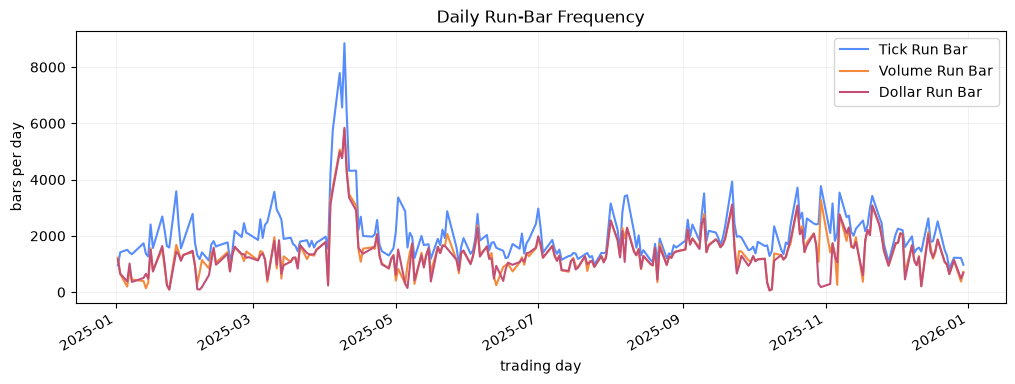

In [7]:
trading_days = pd.DatetimeIndex(
    observations["timestamp"].dt.normalize().drop_duplicates(),
    name="trading_day",
)

run_daily_bar_counts = pd.DataFrame(
    {
        name: result.ohlcv.groupby(result.ohlcv.index.normalize()).size()
        for name, result in run_bar_results.items()
    }
).reindex(trading_days).fillna(0).astype(int)
run_daily_bar_counts.index.name = "trading_day"

ax = run_daily_bar_counts.plot(figsize=(12, 4), lw=1.5)
ax.set_title("Daily Run-Bar Frequency")
ax.set_xlabel("trading day")
ax.set_ylabel("bars per day")
ax.grid(alpha=0.25)
plt.show()